# Data Cleaning - PT Voltec Indonesia
## Analisis Produksi Elektronik H2 2024

**Tujuan:** Membersihkan data produksi mentah agar siap untuk analisis eksplorasi (EDA) dan SQL analysis.

**Langkah-langkah:**
1. Load data mentah
2. Inspeksi awal (shape, info, describe)
3. Penanganan missing values
4. Penghapusan duplikat
5. Validasi dan koreksi tipe data
6. Deteksi dan penanganan outlier
7. Validasi business rules
8. Export data bersih
9. Ringkasan perubahan

---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Konfigurasi path
RAW_DIR = os.path.join('..', 'data', 'raw')
CLEAN_DIR = os.path.join('..', 'data', 'cleaned')
os.makedirs(CLEAN_DIR, exist_ok=True)

# Load semua tabel
production = pd.read_csv(os.path.join(RAW_DIR, 'production_fact.csv'))
line_dim = pd.read_csv(os.path.join(RAW_DIR, 'line_dim.csv'))
machine_dim = pd.read_csv(os.path.join(RAW_DIR, 'machine_dim.csv'))
shift_dim = pd.read_csv(os.path.join(RAW_DIR, 'shift_dim.csv'))
product_dim = pd.read_csv(os.path.join(RAW_DIR, 'product_dim.csv'))

print(f'production_fact : {production.shape}')
print(f'line_dim        : {line_dim.shape}')
print(f'machine_dim     : {machine_dim.shape}')
print(f'shift_dim       : {shift_dim.shape}')
print(f'product_dim     : {product_dim.shape}')

production_fact : (24920, 10)
line_dim        : (5, 4)
machine_dim     : (15, 5)
shift_dim       : (3, 4)
product_dim     : (5, 4)


---
## 2. Inspeksi Awal

In [3]:
# Melihat 5 baris pertama
production.head()

,production_id,production_date,line_id,machine_id,shift_id,product_id,target_qty,output_qty,defect_qty,downtime_minutes
0,1,2024-08-31,5,15.00,1,4,28,26.00,0.00,24.60
1,2,2024-11-03,2,4.00,1,3,16,15.00,0.00,22.40
2,3,2024-12-02,3,9.00,3,5,43,31.00,3.00,59.40
3,4,2024-07-11,4,12.00,3,3,46,38.00,1.00,2.70
4,5,2024-11-03,1,1.00,2,5,17,16.00,0.00,5.20


In [4]:
# Informasi tipe data dan non-null count
production.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24920 entries, 0 to 24919
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   production_id     24920 non-null  int64  
 1   production_date   24920 non-null  object 
 2   line_id           24920 non-null  int64  
 3   machine_id        24795 non-null  float64
 4   shift_id          24920 non-null  int64  
 5   product_id        24920 non-null  int64  
 6   target_qty        24920 non-null  int64  
 7   output_qty        24421 non-null  float64
 8   defect_qty        24544 non-null  float64
 9   downtime_minutes  24672 non-null  float64
dtypes: float64(4), int64(5), object(1)
memory usage: 1.9+ MB


In [5]:
# Statistik deskriptif
production.describe()

,production_id,line_id,machine_id,shift_id,product_id,target_qty,output_qty,defect_qty,downtime_minutes
count,24920.00,24920.00,24795.00,24920.00,24920.00,24920.00,24421.00,24544.00,24672.00
mean,12460.50,3.00,8.00,2.00,3.00,42.58,38.78,1.45,24.91
std,7193.93,1.41,4.32,0.82,1.41,14.19,14.15,5.08,35.08
min,1.00,1.00,1.00,1.00,1.00,13.00,-97.00,0.00,0.00
25%,6230.75,2.00,4.00,1.00,2.00,30.00,28.00,0.00,5.60
50%,12460.50,3.00,8.00,2.00,3.00,48.00,42.00,1.00,14.30
75%,18690.25,4.00,12.00,3.00,4.00,53.00,49.00,2.00,30.90
max,24920.00,5.00,15.00,3.00,5.00,60.00,74.00,244.00,833.42


In [6]:
# Cek tipe data saat ini
print('Tipe data setiap kolom:')
print(production.dtypes)
print(f'\nJumlah baris : {len(production):,}')
print(f'Jumlah kolom : {production.shape[1]}')

Tipe data setiap kolom:
production_id         int64
production_date      object
line_id               int64
machine_id          float64
shift_id              int64
product_id            int64
target_qty            int64
output_qty          float64
defect_qty          float64
downtime_minutes    float64
dtype: object

Jumlah baris : 24,920
Jumlah kolom : 10


---
## 3. Penanganan Missing Values

In [7]:
# Hitung missing values per kolom
missing = production.isnull().sum()
missing_pct = (missing / len(production) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('=== Missing Values Summary ===')
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values Summary ===
                  Missing Count  Missing %
output_qty                  499       2.00
defect_qty                  376       1.51
downtime_minutes            248       1.00
machine_id                  125       0.50

Total missing values: 1248


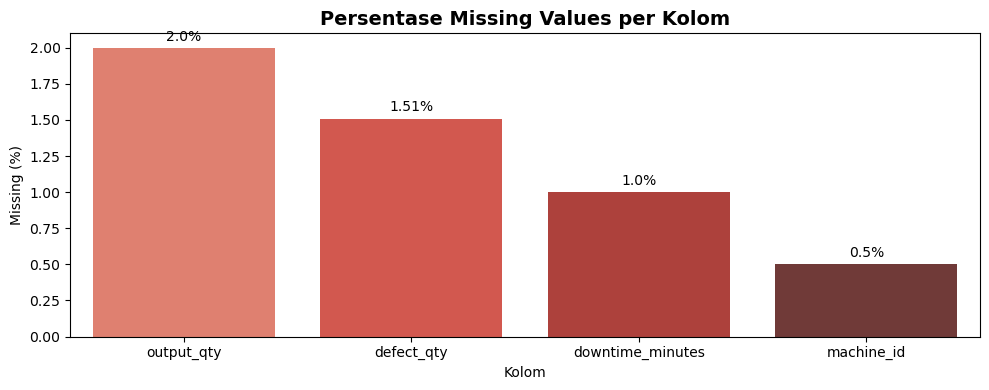

In [8]:
# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0].index
sns.barplot(x=cols_with_missing, y=missing_df.loc[cols_with_missing, 'Missing %'], ax=ax, palette='Reds_d')
ax.set_title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_xlabel('Kolom')
for i, v in enumerate(missing_df.loc[cols_with_missing, 'Missing %']):
    ax.text(i, v + 0.05, f'{v}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
# Strategi penanganan missing values:
# - output_qty: isi dengan median per (line_id, shift_id)
# - defect_qty: isi dengan median per (line_id, product_id)
# - downtime_minutes: isi dengan median per machine_id
# - machine_id: hapus baris karena FK kritis

before_count = len(production)

# Hapus baris dengan machine_id kosong (FK kritis)
production = production.dropna(subset=['machine_id'])
print(f'Baris dihapus (machine_id kosong): {before_count - len(production)}')

# Isi output_qty dengan median per (line_id, shift_id)
production['output_qty'] = production.groupby(['line_id', 'shift_id'])['output_qty'].transform(
    lambda x: x.fillna(x.median())
)

# Isi defect_qty dengan median per (line_id, product_id)
production['defect_qty'] = production.groupby(['line_id', 'product_id'])['defect_qty'].transform(
    lambda x: x.fillna(x.median())
)

# Isi downtime_minutes dengan median per machine_id
production['downtime_minutes'] = production.groupby('machine_id')['downtime_minutes'].transform(
    lambda x: x.fillna(x.median())
).round(1)

print(f'\nMissing values setelah penanganan:')
print(production.isnull().sum().sum(), '(seharusnya 0)')

Baris dihapus (machine_id kosong): 125

Missing values setelah penanganan:
0 (seharusnya 0)


---
## 4. Penghapusan Duplikat

In [10]:
# Cek duplikat berdasarkan semua kolom kecuali production_id
cols_check = [c for c in production.columns if c != 'production_id']
duplicates = production.duplicated(subset=cols_check, keep='first')
print(f'Jumlah baris duplikat: {duplicates.sum()}')
if duplicates.sum() > 0:
    print('\nContoh baris duplikat (5 pertama):')
    display(production[duplicates].head())

Jumlah baris duplikat: 77

Contoh baris duplikat (5 pertama):


,production_id,production_date,line_id,machine_id,shift_id,product_id,target_qty,output_qty,defect_qty,downtime_minutes
1333,1334,2024-11-18,3,9.00,1,1,51,51.00,2.00,2.10
5019,5020,2024-10-22,4,12.00,2,3,51,54.00,1.00,0.00
5712,5713,2024-08-11,2,4.00,2,3,16,16.00,0.00,0.00
5863,5864,2024-11-28,2,4.00,3,3,48,40.00,1.00,22.50
6116,6117,2024-12-03,1,3.00,3,5,52,34.00,4.00,10.30


In [11]:
# Hapus duplikat
before_dup = len(production)
production = production.drop_duplicates(subset=cols_check, keep='first').reset_index(drop=True)
print(f'Baris dihapus (duplikat): {before_dup - len(production)}')
print(f'Jumlah baris sekarang: {len(production):,}')

Baris dihapus (duplikat): 77
Jumlah baris sekarang: 24,718


---
## 5. Validasi dan Koreksi Tipe Data

In [12]:
# Konversi production_date ke datetime
production['production_date'] = pd.to_datetime(production['production_date'])

# Pastikan kolom numerik bertipe integer
int_cols = ['production_id', 'line_id', 'machine_id', 'shift_id', 'product_id', 'target_qty', 'output_qty', 'defect_qty']
for col in int_cols:
    production[col] = production[col].astype(int)

production['downtime_minutes'] = production['downtime_minutes'].astype(float).round(1)

# Urutkan data berdasarkan tanggal secara ascending agar production_id selaras secara kronologis
production = production.sort_values('production_date').reset_index(drop=True)
production['production_id'] = range(1, len(production) + 1)

print('Tipe data setelah koreksi:')
print(production.dtypes)

Tipe data setelah koreksi:
production_id                int64
production_date     datetime64[ns]
line_id                      int64
machine_id                   int64
shift_id                     int64
product_id                   int64
target_qty                   int64
output_qty                   int64
defect_qty                   int64
downtime_minutes           float64
dtype: object


In [13]:
# Validasi rentang tanggal
print(f'Tanggal awal  : {production["production_date"].min()}')
print(f'Tanggal akhir : {production["production_date"].max()}')
print(f'Rentang       : {(production["production_date"].max() - production["production_date"].min()).days + 1} hari')

Tanggal awal  : 2024-07-01 00:00:00
Tanggal akhir : 2024-12-31 00:00:00
Rentang       : 184 hari


---
## 6. Deteksi dan Penanganan Outlier

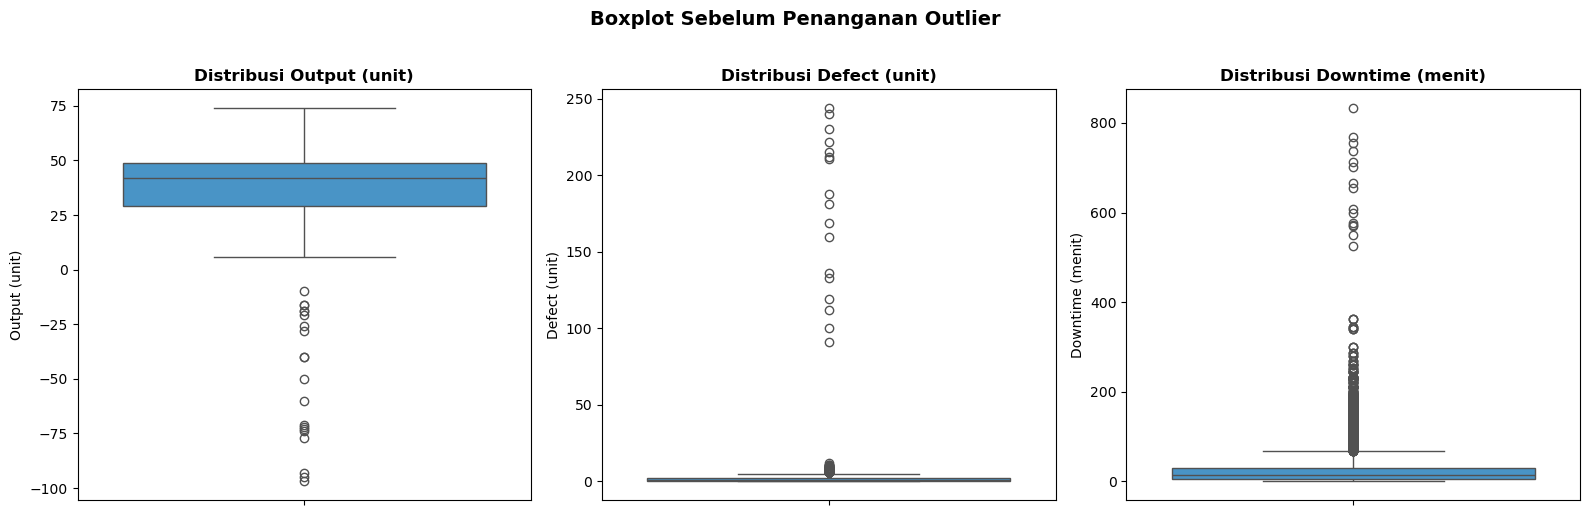

In [14]:
# Visualisasi distribusi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes, ['output_qty', 'defect_qty', 'downtime_minutes'],
                           ['Output (unit)', 'Defect (unit)', 'Downtime (menit)']):
    sns.boxplot(data=production, y=col, ax=ax, color='#3498db')
    ax.set_title(f'Distribusi {title}', fontweight='bold')
    ax.set_ylabel(title)
plt.suptitle('Boxplot Sebelum Penanganan Outlier', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Deteksi outlier dengan IQR method
def detect_outliers_iqr(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)], Q1 - 1.5*IQR, Q3 + 1.5*IQR

for col in ['output_qty', 'defect_qty', 'downtime_minutes']:
    outliers, lower, upper = detect_outliers_iqr(production, col)
    print(f'{col}: {len(outliers)} outlier(s) | Range valid: [{lower:.1f}, {upper:.1f}]')

output_qty: 20 outlier(s) | Range valid: [-1.0, 79.0]
defect_qty: 379 outlier(s) | Range valid: [-3.0, 5.0]
downtime_minutes: 1884 outlier(s) | Range valid: [-32.1, 68.7]


In [16]:
# Penanganan outlier: clipping ke batas IQR
for col in ['output_qty', 'defect_qty', 'downtime_minutes']:
    Q1, Q3 = production[col].quantile(0.25), production[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    clipped = production[col].clip(lower=lower, upper=upper)
    if col == 'downtime_minutes':
        clipped = clipped.round(1)
    changed = (production[col] != clipped).sum()
    production[col] = clipped
    print(f'{col}: {changed} nilai di-clip ke [{lower:.1f}, {upper:.1f}]')

output_qty: 20 nilai di-clip ke [-1.0, 79.0]
defect_qty: 379 nilai di-clip ke [-3.0, 5.0]
downtime_minutes: 1884 nilai di-clip ke [-32.1, 68.7]


---
## 7. Validasi Business Rules

In [17]:
# Business Rule 1: output_qty >= 0
neg_output = (production['output_qty'] < 0).sum()
print(f'1. Output negatif: {neg_output} baris')
production.loc[production['output_qty'] < 0, 'output_qty'] = 0

# Business Rule 2: defect_qty <= output_qty
invalid_defect = (production['defect_qty'] > production['output_qty']).sum()
print(f'2. Defect > Output: {invalid_defect} baris')
mask = production['defect_qty'] > production['output_qty']
production.loc[mask, 'defect_qty'] = production.loc[mask, 'output_qty']

# Business Rule 3: downtime_minutes <= 480
invalid_dt = (production['downtime_minutes'] > 480).sum()
print(f'3. Downtime > 480 menit: {invalid_dt} baris')
production.loc[production['downtime_minutes'] > 480, 'downtime_minutes'] = 480

# Business Rule 4: tanggal dalam rentang H2 2024
invalid_date = ((production['production_date'] < '2024-07-01') | (production['production_date'] > '2024-12-31')).sum()
print(f'4. Tanggal di luar rentang: {invalid_date} baris')

# Business Rule 5: FK valid
for fk_col, valid_set, name in [
    ('line_id', set(line_dim['line_id']), 'Line'),
    ('machine_id', set(machine_dim['machine_id']), 'Machine'),
    ('shift_id', set(shift_dim['shift_id']), 'Shift'),
    ('product_id', set(product_dim['product_id']), 'Product'),
]:
    invalid = (~production[fk_col].isin(valid_set)).sum()
    print(f'5. {name} ID tidak valid: {invalid} baris')

1. Output negatif: 20 baris
2. Defect > Output: 17 baris
3. Downtime > 480 menit: 0 baris
4. Tanggal di luar rentang: 0 baris
5. Line ID tidak valid: 0 baris
5. Machine ID tidak valid: 0 baris
5. Shift ID tidak valid: 0 baris
5. Product ID tidak valid: 0 baris


In [18]:
# Verifikasi akhir
print('=== Verifikasi Business Rules (Pasca Cleaning) ===')
print(f'Output negatif      : {(production["output_qty"] < 0).sum()}')
print(f'Defect > Output     : {(production["defect_qty"] > production["output_qty"]).sum()}')
print(f'Downtime > 480 min  : {(production["downtime_minutes"] > 480).sum()}')
print(f'Missing values      : {production.isnull().sum().sum()}')
checks = [(production['output_qty'] >= 0).all(), (production['defect_qty'] <= production['output_qty']).all(),
           (production['downtime_minutes'] <= 480).all(), production.isnull().sum().sum() == 0]
print('\nSemua business rules terpenuhi!' if all(checks) else '\nMasih ada pelanggaran!')

=== Verifikasi Business Rules (Pasca Cleaning) ===
Output negatif      : 0
Defect > Output     : 0
Downtime > 480 min  : 0
Missing values      : 0

Semua business rules terpenuhi!


---
## 8. Export Data Bersih

In [19]:
production.to_csv(os.path.join(CLEAN_DIR, 'production_fact_cleaned.csv'), index=False)
line_dim.to_csv(os.path.join(CLEAN_DIR, 'line_dim_cleaned.csv'), index=False)
machine_dim.to_csv(os.path.join(CLEAN_DIR, 'machine_dim_cleaned.csv'), index=False)
shift_dim.to_csv(os.path.join(CLEAN_DIR, 'shift_dim_cleaned.csv'), index=False)
product_dim.to_csv(os.path.join(CLEAN_DIR, 'product_dim_cleaned.csv'), index=False)

print('Data bersih disimpan ke:', CLEAN_DIR)
for f in os.listdir(CLEAN_DIR):
    size = os.path.getsize(os.path.join(CLEAN_DIR, f)) / 1024
    print(f'  {f:40s} {size:8.1f} KB')

Data bersih disimpan ke: ..\data\cleaned


  line_dim_cleaned.csv                          0.2 KB
  machine_dim_cleaned.csv                       0.6 KB
  production_fact_cleaned.csv                 930.9 KB
  product_dim_cleaned.csv                       0.2 KB
  shift_dim_cleaned.csv                         0.1 KB


---
## 9. Ringkasan Perubahan

In [20]:
# Muat ulang data mentah untuk perbandingan
raw = pd.read_csv(os.path.join(RAW_DIR, 'production_fact.csv'))

# Hitung metrik raw data dengan aman
raw_valid = raw.dropna(subset=['defect_qty', 'output_qty'])
raw_defect_gt_output = (raw_valid['defect_qty'] > raw_valid['output_qty']).sum()

summary = pd.DataFrame({
    'Metrik': ['Jumlah baris', 'Missing values', 'Duplikat', 'Output negatif', 'Defect > Output', 'Downtime > 480'],
    'Sebelum': [
        f'{len(raw):,}', f'{raw.isnull().sum().sum():,}',
        f'{raw.duplicated(subset=[c for c in raw.columns if c != "production_id"]).sum():,}',
        f'{(raw["output_qty"].dropna() < 0).sum():,}',
        f'{raw_defect_gt_output:,}',
        f'{(raw["downtime_minutes"].dropna() > 480).sum():,}',
    ],
    'Sesudah': [
        f'{len(production):,}', f'{production.isnull().sum().sum():,}',
        f'{production.duplicated(subset=[c for c in production.columns if c != "production_id"]).sum():,}',
        f'{(production["output_qty"] < 0).sum():,}',
        f'{(production["defect_qty"] > production["output_qty"]).sum():,}',
        f'{(production["downtime_minutes"] > 480).sum():,}',
    ]
})

print('=' * 60)
print('RINGKASAN DATA CLEANING')
print('=' * 60)
display(summary)

RINGKASAN DATA CLEANING


,Metrik,Sebelum,Sesudah
0,Jumlah baris,"24,920","24,718"
1,Missing values,"1,248",0
2,Duplikat,78,1
3,Output negatif,20,0
4,Defect > Output,38,0
5,Downtime > 480,15,0


In [21]:
# Preview data bersih
print('Preview data bersih:')
production.head(10)

Preview data bersih:


,production_id,production_date,line_id,machine_id,shift_id,product_id,target_qty,output_qty,defect_qty,downtime_minutes
0,1,2024-07-01,3,7,1,5,51,53,4,49.30
1,2,2024-07-01,2,5,3,4,42,41,2,0.00
2,3,2024-07-01,5,13,1,1,45,50,0,3.60
3,4,2024-07-01,1,3,2,1,50,53,0,2.60
4,5,2024-07-01,4,11,1,3,47,47,0,22.00
5,6,2024-07-01,2,5,1,4,49,54,1,9.30
6,7,2024-07-01,5,13,1,4,45,53,1,3.60
7,8,2024-07-01,4,11,2,3,44,40,1,11.10
8,9,2024-07-01,5,15,2,5,43,42,2,31.90
9,10,2024-07-01,3,7,3,5,43,37,5,68.70


In [22]:
production.describe()

,production_id,production_date,line_id,machine_id,shift_id,product_id,target_qty,output_qty,defect_qty,downtime_minutes
count,24718.00,24718,24718.00,24718.00,24718.00,24718.00,24718.00,24718.00,24718.00,24718.00
mean,12359.50,2024-09-30 12:50:27.041022976,3.00,8.00,2.00,3.00,42.59,38.92,1.29,21.40
min,1.00,2024-07-01 00:00:00,1.00,1.00,1.00,1.00,13.00,0.00,0.00,0.00
25%,6180.25,2024-08-16 00:00:00,2.00,4.00,1.00,2.00,30.00,29.00,0.00,5.70
50%,12359.50,2024-10-01 00:00:00,3.00,8.00,2.00,3.00,48.00,42.00,1.00,14.35
75%,18538.75,2024-11-16 00:00:00,4.00,12.00,3.00,4.00,53.00,49.00,2.00,30.90
max,24718.00,2024-12-31 00:00:00,5.00,15.00,3.00,5.00,60.00,74.00,5.00,68.70
std,7135.62,NaN,1.41,4.32,0.82,1.41,14.18,13.82,1.21,20.71


---
## Kesimpulan Data Cleaning

Data produksi PT Voltec Indonesia telah dibersihkan:

1. **Missing values** ditangani dengan median grouping per konteks bisnis
2. **Duplikat** dihapus berdasarkan semua kolom kecuali production_id
3. **Tipe data** dikonversi ke format yang sesuai
4. **Outlier** ditangani dengan IQR clipping
5. **Business rules** divalidasi dan dikoreksi

Data bersih siap untuk EDA, SQL Analysis, dan Dashboard Power BI.